<a href="https://colab.research.google.com/github/aleksandrabegovic/apple_sentiment_analiza/blob/main/SentimentAmazon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip -q install yfinance

import pandas as pd
import numpy as np
import yfinance as yf
#Potrebne biblioteke za dalje analize.

In [3]:
from google.colab import files
uploaded = files.upload()
#Podaci su učitani u okruženje, nakon čega su dalje obrađeni.

Saving apple_news_data.csv to apple_news_data.csv


In [4]:
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df.shape, df.columns
#Prikaz osnovnih informacija o datasetu, broj redova, broj kolona, kao i informacija o tome koje sve kolone postoje.

((29752, 10),
 Index(['date', 'title', 'content', 'link', 'symbols', 'tags',
        'sentiment_polarity', 'sentiment_neg', 'sentiment_neu',
        'sentiment_pos'],
       dtype='object'))

In [5]:
df.head(5)
#Prikaz prvih 5 redova, kako bismo videli sa kojim podacima radimo.

,date,title,content,link,symbols,tags,sentiment_polarity,sentiment_neg,sentiment_neu,sentiment_pos
0,2024-11-27T16:39:00+00:00,Berkshire Stock Hits Record Even as Company Re...,"Warren Buffett’s caution, his advancing age, a...",https://finance.yahoo.com/m/f5df3aa4-364b-31d6...,"0R2V.IL, AAPL.BA, AAPL.MX, AAPL.NEO, AAPL.SN, ...",NaN,0.0,0.0,1.0,0.0
1,2024-11-26T00:00:00+00:00,What Is a Stock Market Index?,What Is a Stock Market Index?,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMZN.US, MSFT.US",NaN,0.0,0.0,1.0,0.0
2,2024-11-26T00:00:00+00:00,"Could Investing $1,000 in Apple Make You a Mil...","Could Investing $1,000 in Apple Make You a Mil...",https://www.fool.com/investing/2024/11/26/coul...,AAPL.US,NaN,0.0,0.0,1.0,0.0
3,2024-11-26T00:00:00+00:00,Dow Jones Industrial Average,Dow Jones Industrial Average,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMGN.US, AMZN.US, CSCO.US, GOOG.US, G...",NaN,0.0,0.0,1.0,0.0
4,2024-11-26T00:00:00+00:00,What Is the S&P 500 Index?,What Is the S&P 500 Index?,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMZN.US, GOOG.US, GOOGL.US, META.US, ...",NaN,0.0,0.0,1.0,0.0


In [6]:
df["date"] = pd.to_datetime(df["date"])
df[["date"]].head()
# Konverzija kolone 'date' u datetime format radi vremenskog
# usklađivanja finansijskih vesti sa podacima o cenama akcija.

,date
0,2024-11-27 16:39:00+00:00
1,2024-11-26 00:00:00+00:00
2,2024-11-26 00:00:00+00:00
3,2024-11-26 00:00:00+00:00
4,2024-11-26 00:00:00+00:00


In [7]:
amzn_df = df[df["symbols"].str.contains("AMZN.US", na=False)].copy()

print("Broj AMZN.US vesti:", len(amzn_df))

Broj AMZN.US vesti: 5389


In [8]:
amzn_df["year"] = pd.to_datetime(amzn_df["date"]).dt.year
amzn_df["year"].value_counts().sort_index()

,count
year,
2017,1
2018,1
2020,53
2021,1707
2022,1969
2023,1153
2024,505


In [9]:
amzn_df.to_csv("/content/drive/MyDrive/amazon_news.csv", index=False)

In [10]:
row = amzn_df.sample(1).iloc[0]

print("DATUM:", row["date"])
print("TITLE:", row["title"])
print("CONTENT:", row["content"])

DATUM: 2022-08-19 18:44:30+00:00
TITLE: 10 Best Fidelity Funds to Buy Now
CONTENT: In turbulent times, investors would be well served considering the best Fidelity funds to buy now. Primarily, Fidelity represents an organization with a well-earned reputation for viability and stability.

According to the U.S. Census Bureau, our population grew at 0.1% in 2021, the slowest rate since the founding of the nation. While so much talk exists in the media about labor and inflation, prior paradigms always featured a rising population level. In contrast, we could be facing declining demographic trends, which inherently bolster the best Fidelity funds to buy now.

Put another way, we’re navigating uncharted territory so we’re making things up as we go along.

InvestorPlace - Stock Market News, Stock Advice & Trading Tips

Another factor to consider with the best Fidelity funds to buy now is their diversity. Investors can gain exposure to various markets and themes. Further, if any one individual

In [11]:
!pip install yfinance

In [12]:
import yfinance as yf
import pandas as pd

In [13]:
amzn_prices = yf.download("AMZN", start="2017-01-01", end="2024-12-31")

amzn_prices = amzn_prices.reset_index()

amzn_prices = amzn_prices.rename(columns={
    "Date": "date",
    "Close": "close"
})

/tmp/ipykernel_1027/68820970.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  amzn_prices = yf.download("AMZN", start="2017-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


In [14]:
amzn_df["date"] = pd.to_datetime(amzn_df["date"]).dt.date
amzn_prices["date"] = pd.to_datetime(amzn_prices["date"]).dt.date


amzn_df["date"] = pd.to_datetime(amzn_df["date"])
amzn_prices["date"] = pd.to_datetime(amzn_prices["date"])


amzn_df = amzn_df.sort_values("date")
amzn_prices = amzn_prices.sort_values("date")


amzn_prices.columns = amzn_prices.columns.droplevel(1)
amzn_prices = amzn_prices.rename(columns={"Close": "close"})

In [23]:
import pandas as pd

# 1) priprema price tabele
amzn_prices = amzn_prices.sort_values("date").copy()

amzn_prices["close_t"] = amzn_prices["close"]
amzn_prices["close_t1"] = amzn_prices["close"].shift(-1)
amzn_prices["close_t2"] = amzn_prices["close"].shift(-2)
amzn_prices["close_t3"] = amzn_prices["close"].shift(-3)

amzn_prices["open_t1"] = amzn_prices["Open"].shift(-1)
amzn_prices["open_t2"] = amzn_prices["Open"].shift(-2)


amzn_prices["high_t1"] = amzn_prices["High"].shift(-1)
amzn_prices["high_t2"] = amzn_prices["High"].shift(-2)
amzn_prices["high_t3"] = amzn_prices["High"].shift(-3)

amzn_prices["low_t1"] = amzn_prices["Low"].shift(-1)
amzn_prices["low_t2"] = amzn_prices["Low"].shift(-2)
amzn_prices["low_t3"] = amzn_prices["Low"].shift(-3)

amzn_prices["avg_t"] = (
    amzn_prices["Open"] +
    amzn_prices["High"] +
    amzn_prices["Low"] +
    amzn_prices["close"]
) / 4

amzn_prices["avg_t1"] = amzn_prices["avg_t"].shift(-1)

# 2) merge vesti sa sledećim trading danom
amzn_merged = pd.merge_asof(
    amzn_df.sort_values("date"),
    amzn_prices[[
        "date",
        "close_t", "close_t1", "close_t2", "close_t3",
        "open_t1", "open_t2",
        "high_t1", "high_t2", "high_t3",
        "low_t1", "low_t2", "low_t3",
        "avg_t", "avg_t1"
    ]],
    on="date",
    direction="forward"
)

# 3) prinosi za osnovnu analizu

amzn_merged["return_close_close"] = (
    amzn_merged["close_t1"] - amzn_merged["close_t"]
) / amzn_merged["close_t"]

amzn_merged["return_open_close"] = (
    amzn_merged["close_t1"] - amzn_merged["open_t1"]
) / amzn_merged["open_t1"]

amzn_merged["return_open_open"] = (
    amzn_merged["open_t2"] - amzn_merged["open_t1"]
) / amzn_merged["open_t1"]

amzn_merged["return_avg_avg"] = (
    amzn_merged["avg_t1"] - amzn_merged["avg_t"]
) / amzn_merged["avg_t"]

# 4) dodatni prinosi za modele 2 i 3 dana

amzn_merged["return_2d"] = (
    amzn_merged["close_t2"] - amzn_merged["close_t"]
) / amzn_merged["close_t"]

amzn_merged["return_3d"] = (
    amzn_merged["close_t3"] - amzn_merged["close_t"]
) / amzn_merged["close_t"]

# 5) targeti za neuronsku mrežu: UP = 1, DOWN = 0

amzn_merged["y_1d"] = (amzn_merged["return_close_close"] > 0).astype(int)
amzn_merged["y_2d"] = (amzn_merged["return_2d"] > 0).astype(int)
amzn_merged["y_3d"] = (amzn_merged["return_3d"] > 0).astype(int)

# 6)

amzn_merged["max_high_3d"] = amzn_merged[["high_t1", "high_t2", "high_t3"]].max(axis=1)
amzn_merged["min_low_3d"] = amzn_merged[["low_t1", "low_t2", "low_t3"]].min(axis=1)

amzn_merged["up_move_3d"] = amzn_merged["max_high_3d"] - amzn_merged["close_t"]
amzn_merged["down_move_3d"] = amzn_merged["min_low_3d"] - amzn_merged["close_t"]

amzn_merged["y_prof_3d"] = (
    abs(amzn_merged["up_move_3d"]) > abs(amzn_merged["down_move_3d"])
).astype(int)

# 7)
amzn_merged["company"] = "AMZN"

# 8)
amzn_merged = amzn_merged.dropna(subset=[
    "return_close_close", "return_2d", "return_3d",
    "max_high_3d", "min_low_3d"
])



In [24]:
amzn_merged[["date", "title", "close_t", "close_t1", "return_close_close","return_open_open","return_open_close","return_avg_avg"]].head()

,date,title,close_t,close_t1,return_close_close,return_open_open,return_open_close,return_avg_avg
0,2017-10-05,New Research: Key Drivers of Growth for Micros...,49.042500,49.479000,0.008900,0.018039,0.014288,0.008870
1,2018-03-16,Top 100 Reputable Companies Around the Globe A...,78.584000,77.246498,-0.017020,-0.002695,-0.006176,-0.019898
2,2020-03-30,Buying What the Fed Buys,98.197502,97.486000,-0.007246,-0.015975,-0.007448,0.010080
3,2020-04-09,The Top 3 Ways to Trade a Pullback in Volatility,102.138000,108.443497,0.061735,0.078662,0.063172,0.032993
4,2020-05-06,Crazy Trading on China's Nasdaq Has Its Own Logic,117.563004,118.380501,0.006954,-0.001112,-0.003019,0.011044


In [25]:
d = pd.to_datetime("2021-07-28")

amzn_merged[amzn_merged["date"].dt.date == d.date()][["close_t","close_t1"]].drop_duplicates()

,close_t,close_t1
958,181.516006,179.996002


In [26]:
amzn_merged["direction_close_close"] = amzn_merged["return_close_close"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

amzn_merged["direction_open_close"] = amzn_merged["return_open_close"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

amzn_merged["direction_open_open"] = amzn_merged["return_open_open"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

amzn_merged["direction_avg_avg"] = amzn_merged["return_avg_avg"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

In [27]:
amzn_merged["direction_close_close"].value_counts()

,count
direction_close_close,
DOWN,2705
UP,2684


In [28]:
amzn_merged["direction_open_close"].value_counts()

,count
direction_open_close,
DOWN,2776
UP,2613


In [29]:
amzn_merged["direction_open_open"].value_counts()

,count
direction_open_open,
UP,2771
DOWN,2618


In [30]:
amzn_merged["direction_avg_avg"].value_counts()

,count
direction_avg_avg,
UP,2707
DOWN,2682


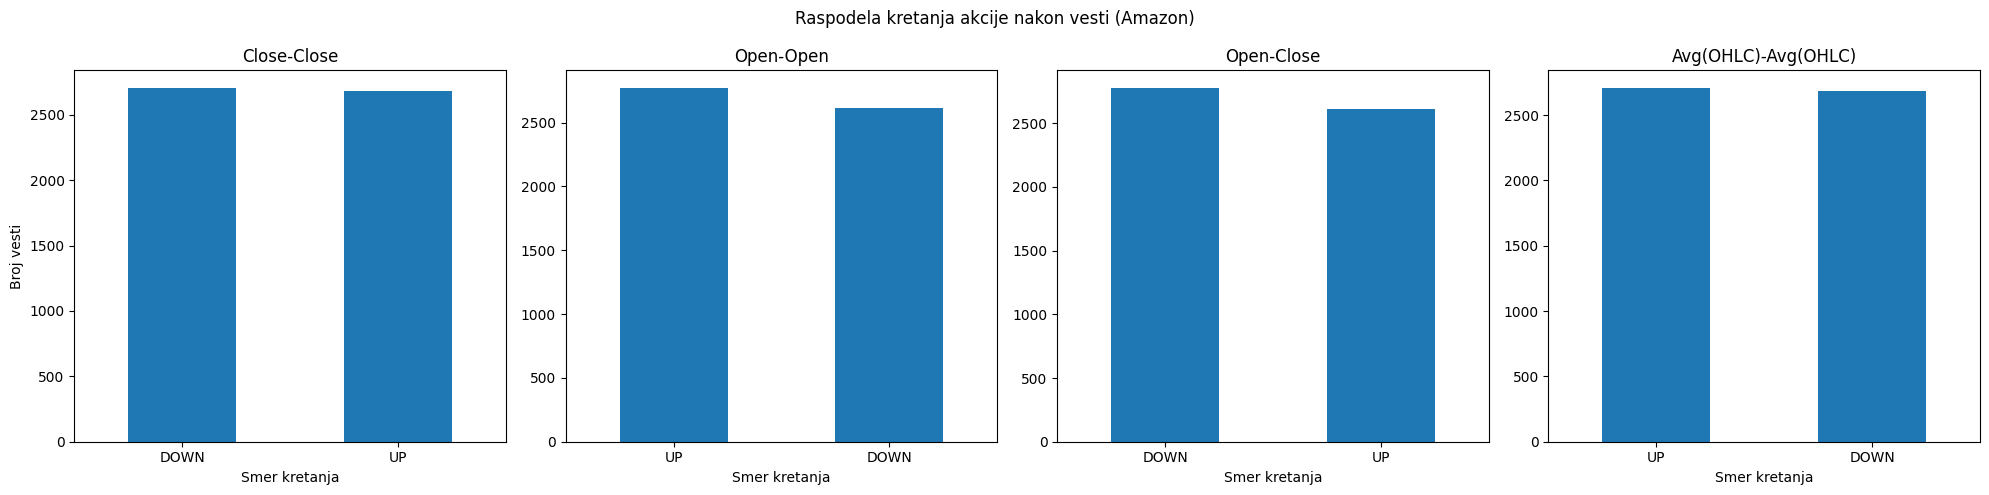

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20,5))

# close-close
amzn_merged["direction_close_close"].value_counts().plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Close-Close")
axes[0].set_xlabel("Smer kretanja")
axes[0].set_ylabel("Broj vesti")
axes[0].tick_params(axis='x', rotation=0)

# open-open
amzn_merged["direction_open_open"].value_counts().plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("Open-Open")
axes[1].set_xlabel("Smer kretanja")
axes[1].tick_params(axis='x', rotation=0)

# open-close
amzn_merged["direction_open_close"].value_counts().plot(
    kind="bar", ax=axes[2]
)
axes[2].set_title("Open-Close")
axes[2].set_xlabel("Smer kretanja")
axes[2].tick_params(axis='x', rotation=0)

# avg-avg
amzn_merged["direction_avg_avg"].value_counts().plot(
    kind="bar", ax=axes[3]
)
axes[3].set_title("Avg(OHLC)-Avg(OHLC)")
axes[3].set_xlabel("Smer kretanja")
axes[3].tick_params(axis='x', rotation=0)

plt.suptitle("Raspodela kretanja akcije nakon vesti (Amazon)")

plt.tight_layout()
plt.show()

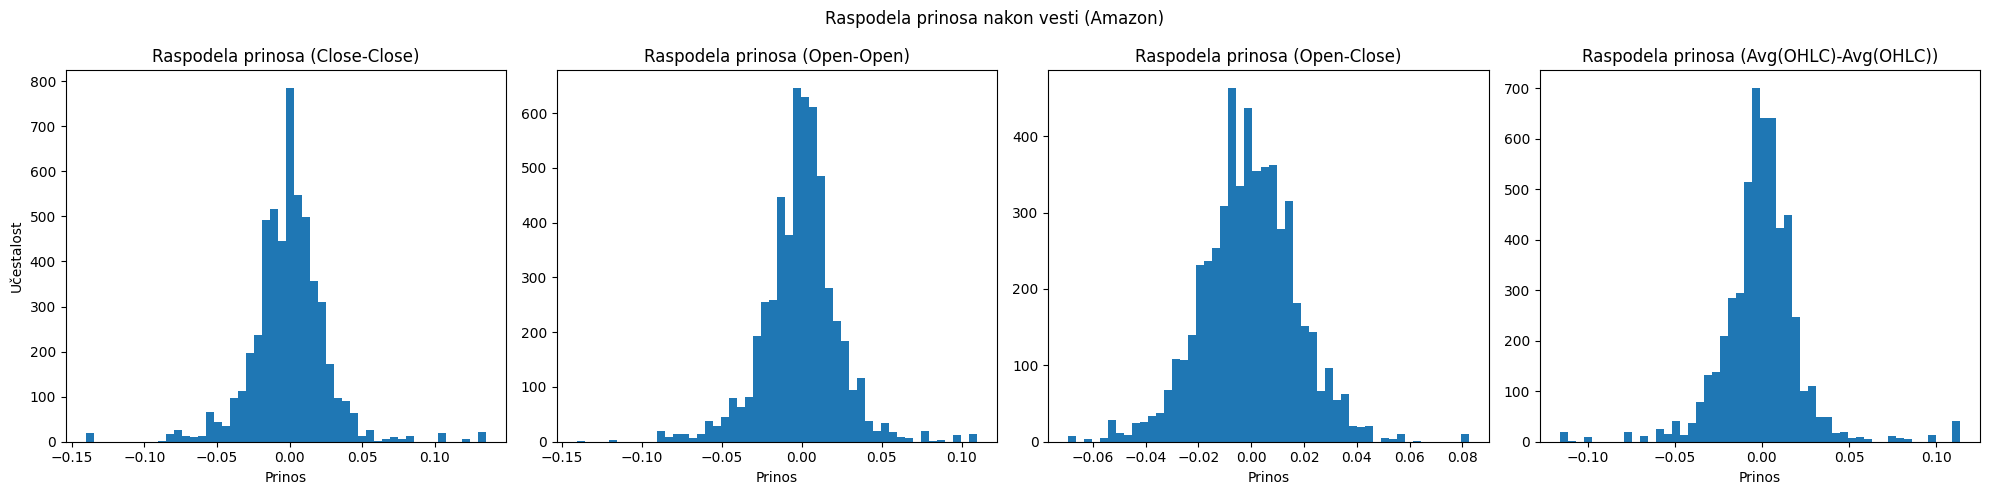

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20,5))

# Close-Close
axes[0].hist(amzn_merged["return_close_close"].dropna(), bins=50)
axes[0].set_title("Raspodela prinosa (Close-Close)")
axes[0].set_xlabel("Prinos")
axes[0].set_ylabel("Učestalost")

# Open-Open
axes[1].hist(amzn_merged["return_open_open"].dropna(), bins=50)
axes[1].set_title("Raspodela prinosa (Open-Open)")
axes[1].set_xlabel("Prinos")

# Open-Close
axes[2].hist(amzn_merged["return_open_close"].dropna(), bins=50)
axes[2].set_title("Raspodela prinosa (Open-Close)")
axes[2].set_xlabel("Prinos")

# Avg-Avg
axes[3].hist(amzn_merged["return_avg_avg"].dropna(), bins=50)
axes[3].set_title("Raspodela prinosa (Avg(OHLC)-Avg(OHLC))")
axes[3].set_xlabel("Prinos")

plt.suptitle("Raspodela prinosa nakon vesti (Amazon)")

plt.tight_layout()
plt.show()

In [33]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

In [ ]:
from typing import Optional
from enum import Enum
from pydantic import BaseModel, Field


class Sentiment(str, Enum):
    NEGATIVE = "negative"
    NEUTRAL = "neutral"
    POSITIVE = "positive"


class Topic(str, Enum):
    ECOMMERCE = "ecommerce_online_retail"
    AWS = "aws_cloud_services"
    LOGISTICS = "logistics_delivery_network"
    PRIME = "prime_subscription_services"
    ADVERTISING = "amazon_advertising_business"
    AI = "ai_ml"
    REGULATION = "regulation_antitrust"
    LEGAL = "legal_lawsuit"
    MACRO = "macro_economy_rates_inflation"
    MERGERS = "mna_partnerships"
    OTHER = "other"


class NewsAnnotation(BaseModel):
    """Structured annotation for Amazon-related financial news."""

    sentiment: Optional[Sentiment] = Field(
        default=None,
        description="Overall sentiment expressed toward Amazon in the news.",
        examples=[Sentiment.NEGATIVE]
    )

    sentiment_score: Optional[float] = Field(
        default=None,
        description="Sentiment score between -1 and 1 where -1 is very negative, 0 neutral, and 1 very positive.",
        examples=[-0.8, 0.0, 0.7]
    )

    topic: Optional[Topic] = Field(
        default=None,
        description="Main topic of the news related to Amazon. Choose the closest single category.",
        examples=[Topic.ECOMMERCE]
    )

In [ ]:
import pandas as pd

# funkcija za spajanje title i content
def combine_title_content(row, max_chars=2000):
    title = str(row.get("title", "") or "").strip()
    content = str(row.get("content", "") or "").strip()

    if len(content) > max_chars:
        content = content[:max_chars]

    if content:
        return f"TITLE: {title}\nCONTENT: {content}"

    return f"TITLE: {title}"


amzn_merged["text_for_ie"] = amzn_merged.apply(combine_title_content, axis=1)

amzn_merged[["text_for_ie"]].head(2)

,text_for_ie
0,TITLE: New Research: Key Drivers of Growth for...
1,TITLE: Top 100 Reputable Companies Around the ...


In [34]:
!pip -q install openai langchain langchain-openai pydantic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 4.6 MB/s eta 0:00:00


In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

system_msg = """
You are an expert financial information extraction agent.
Determine Amazon-targeted sentiment based on the impact on Amazon.com, Inc. (Amazon, AMZN).

Return:
- sentiment: EXACTLY one of (positive, neutral, negative)
- sentiment_score: a number between -1 and 1

Rules for sentiment_score:
- -1 = extremely negative news for Amazon
- 0 = neutral impact
- 1 = extremely positive news
- intermediate values allowed (e.g., -0.3, 0.6)

The sentiment_score must be consistent with the sentiment label.

If Amazon is mentioned but the impact is unclear, return neutral and sentiment_score = 0.
Return null ONLY if Amazon is not mentioned at all.
Use lowercase only.
"""

prompt = ChatPromptTemplate.from_messages([
    ("system", system_msg),
    ("human", "Analyze the following Amazon-related news:\n{text}")
])

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

ie_chain = prompt | llm.with_structured_output(NewsAnnotation)

In [ ]:
from time import sleep
import pandas as pd

def tag_df_openai(
    df: pd.DataFrame,
    text_col="text_for_ie",
    sleep_sec=0.4,
    save_every=100,
    save_path=None
):
    """
    Automatska anotacija finansijskih vesti pomoću LLM modela
    za Amazon kompaniju.
    """

    out = df.copy()
    sentiments, scores, topics = [], [], []

    for i, txt in enumerate(out[text_col], start=1):
        try:
            res = ie_chain.invoke({"text": txt})

            sentiments.append(res.sentiment.value if res.sentiment else None)
            scores.append(res.sentiment_score if res.sentiment_score is not None else None)
            topics.append(res.topic.value if res.topic else None)

        except Exception:
            sentiments.append(None)
            scores.append(None)
            topics.append(None)

        if i % 50 == 0:
            print(f"Processed {i} rows")

        if save_path and i % save_every == 0:
            out.loc[:i-1, "sentiment"] = sentiments
            out.loc[:i-1, "sentiment_score"] = scores
            out.loc[:i-1, "topic"] = topics
            out.to_csv(save_path, index=False)

        sleep(sleep_sec)

    out["sentiment"] = sentiments
    out["sentiment_score"] = scores
    out["topic"] = topics

    # FINALNO ČUVANJE
    if save_path:
        out.to_csv(save_path, index=False)
        print(f"Final save completed: {save_path}")

    return out

In [ ]:
amzn_tagged = tag_df_openai(
    amzn_merged,
    text_col="text_for_ie",
    save_path="/content/drive/MyDrive/amzn_news_tagged2.csv"
)

Processed 50 rows
Processed 100 rows
Processed 150 rows
Processed 200 rows
Processed 250 rows
Processed 300 rows
Processed 350 rows
Processed 400 rows
Processed 450 rows
Processed 500 rows
Processed 550 rows
Processed 600 rows
Processed 650 rows
Processed 700 rows
Processed 750 rows
Processed 800 rows
Processed 850 rows
Processed 900 rows
Processed 950 rows
Processed 1000 rows
Processed 1050 rows
Processed 1100 rows
Processed 1150 rows
Processed 1200 rows
Processed 1250 rows
Processed 1300 rows
Processed 1350 rows
Processed 1400 rows
Processed 1450 rows
Processed 1500 rows
Processed 1550 rows
Processed 1600 rows
Processed 1650 rows
Processed 1700 rows
Processed 1750 rows
Processed 1800 rows
Processed 1850 rows
Processed 1900 rows
Processed 1950 rows
Processed 2000 rows
Processed 2050 rows
Processed 2100 rows
Processed 2150 rows
Processed 2200 rows
Processed 2250 rows
Processed 2300 rows
Processed 2350 rows
Processed 2400 rows
Processed 2450 rows
Processed 2500 rows
Processed 2550 rows


In [35]:
import pandas as pd

amzn_tagged = pd.read_csv("/content/drive/MyDrive/amzn_news_tagged2.csv")

In [36]:
amzn_tagged.columns

Index(['date', 'title', 'content', 'link', 'symbols', 'tags',
       'sentiment_polarity', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos',
       'year', 'close_t', 'close_t1', 'open_t1', 'open_t2', 'avg_t', 'avg_t1',
       'return_close_close', 'return_open_close', 'return_open_open',
       'return_avg_avg', 'direction_close_close', 'direction_open_close',
       'direction_open_open', 'direction_avg_avg', 'text_for_ie', 'sentiment',
       'sentiment_score', 'topic'],
      dtype='object')

In [37]:
amzn_tagged[["date", "title", "sentiment", "sentiment_score", "topic"]].head(10)

,date,title,sentiment,sentiment_score,topic
0,2017-10-05,New Research: Key Drivers of Growth for Micros...,neutral,0.0,other
1,2018-03-16,Top 100 Reputable Companies Around the Globe A...,positive,0.7,other
2,2020-03-30,Buying What the Fed Buys,neutral,0.0,macro_economy_rates_inflation
3,2020-04-09,The Top 3 Ways to Trade a Pullback in Volatility,neutral,0.0,macro_economy_rates_inflation
4,2020-05-06,Crazy Trading on China's Nasdaq Has Its Own Logic,neutral,0.0,other
5,2020-05-07,Nasdaq Stock Exchange president on IPO outlook...,neutral,0.0,macro_economy_rates_inflation
6,2020-05-12,Not Just Fun And Games: How Esports Could Offe...,positive,0.6,other
7,2020-05-15,Urbem's 'Quality Strategy' Series: Cash Is King,neutral,0.0,other
8,2020-05-20,The Robots-Are-Taking-Our-Jobs Threat Gets Real,neutral,0.0,other
9,2020-06-19,The 3 Best Vanguard ETFs for a Long-Term Reti...,neutral,0.0,other


In [38]:
amzn_tagged["sentiment"].value_counts()

,count
sentiment,
neutral,3767
positive,856
negative,766


In [39]:
amzn_tagged["sentiment_score"].describe()

,sentiment_score
count,5389.000000
mean,0.023760
std,0.351858
min,-0.900000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [40]:
amzn_tagged[["sentiment","sentiment_score"]].head(20)

,sentiment,sentiment_score
0,neutral,0.0
1,positive,0.7
2,neutral,0.0
3,neutral,0.0
4,neutral,0.0
5,neutral,0.0
6,positive,0.6
7,neutral,0.0
8,neutral,0.0
9,neutral,0.0


In [41]:
amzn_tagged["date_only"] = pd.to_datetime(amzn_tagged["date"]).dt.date

In [42]:
sent_map = {
    "positive": 1,
    "neutral": 0,
    "negative": -1
}

amzn_tagged["sentiment_num"] = amzn_tagged["sentiment"].map(sent_map)

In [43]:
daily_sentiment_class = amzn_tagged.groupby("date_only").agg(
    daily_sentiment_class=("sentiment_num", "mean"),
    news_count=("sentiment_num", "count")
).reset_index()

In [44]:
daily_sentiment_class.head(20)

,date_only,daily_sentiment_class,news_count
0,2017-10-05,0.0,1
1,2018-03-16,1.0,1
2,2020-03-30,0.0,1
3,2020-04-09,0.0,1
4,2020-05-06,0.0,1
5,2020-05-07,0.0,1
6,2020-05-12,1.0,1
7,2020-05-15,0.0,1
8,2020-05-20,0.0,1
9,2020-06-19,0.0,1


In [45]:
daily_sentiment_score = amzn_tagged.groupby("date_only").agg(
    daily_sentiment_score=("sentiment_score", "mean"),
    news_count=("sentiment_score", "count")
).reset_index()

In [46]:
daily_sentiment_score.head(20)

,date_only,daily_sentiment_score,news_count
0,2017-10-05,0.0,1
1,2018-03-16,0.7,1
2,2020-03-30,0.0,1
3,2020-04-09,0.0,1
4,2020-05-06,0.0,1
5,2020-05-07,0.0,1
6,2020-05-12,0.6,1
7,2020-05-15,0.0,1
8,2020-05-20,0.0,1
9,2020-06-19,0.0,1


In [47]:
daily_sentiment = amzn_tagged.groupby("date_only").agg(
    daily_sentiment_class=("sentiment_num", "mean"),
    daily_sentiment_score=("sentiment_score", "mean"),
    news_count=("title", "count"),
    return_close_close=("return_close_close", "first"),
    return_open_close=("return_open_close", "first"),
    return_open_open=("return_open_open", "first"),
    return_avg_avg=("return_avg_avg", "first")
).reset_index()

In [48]:
d = pd.to_datetime("2021-11-03").date()

daily_sentiment[daily_sentiment["date_only"] == d]

,date_only,daily_sentiment_class,daily_sentiment_score,news_count,return_close_close,return_open_close,return_open_open,return_avg_avg
289,2021-11-03,0.75,0.475,4,0.027482,0.031751,0.031751,0.024294


In [49]:
daily_sentiment.groupby(pd.cut(
    daily_sentiment["daily_sentiment_score"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
))[[
    "return_close_close",
    "return_open_close",
    "return_open_open",
    "return_avg_avg"
]].mean()

/tmp/ipykernel_1027/172947486.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_sentiment.groupby(pd.cut(


,return_close_close,return_open_close,return_open_open,return_avg_avg
daily_sentiment_score,,,,
negative,-0.002123,-0.000777,-0.001324,-0.003700
neutral,0.001009,0.000244,0.001052,0.001086
positive,-0.000570,-0.001201,-0.000369,0.000317


In [50]:
daily_sentiment.groupby(pd.cut(
    daily_sentiment["daily_sentiment_class"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
), observed=True)[[
    "return_close_close",
    "return_open_close",
    "return_open_open",
    "return_avg_avg"
]].mean()

,return_close_close,return_open_close,return_open_open,return_avg_avg
daily_sentiment_class,,,,
negative,-0.002490,-0.000898,-0.002430,-0.004465
neutral,0.000922,0.000085,0.001426,0.001076
positive,-0.000011,-0.000793,-0.000499,0.000975


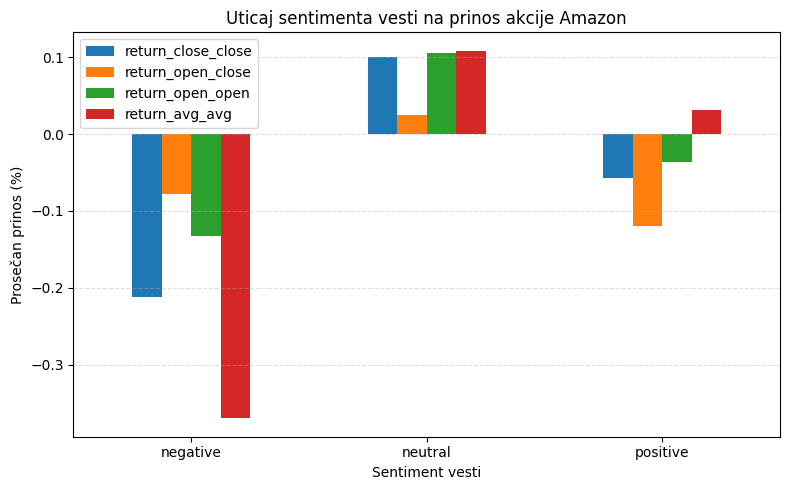

In [51]:
import matplotlib.pyplot as plt

returns_by_sentiment = daily_sentiment.groupby(pd.cut(
    daily_sentiment["daily_sentiment_score"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
), observed=True)[[
    "return_close_close",
    "return_open_close",
    "return_open_open",
    "return_avg_avg"
]].mean()

# u procente
returns_by_sentiment_percent = returns_by_sentiment * 100

# plot
returns_by_sentiment_percent.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Uticaj sentimenta vesti na prinos akcije Amazon")
plt.xlabel("Sentiment vesti")
plt.ylabel("Prosečan prinos (%)")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

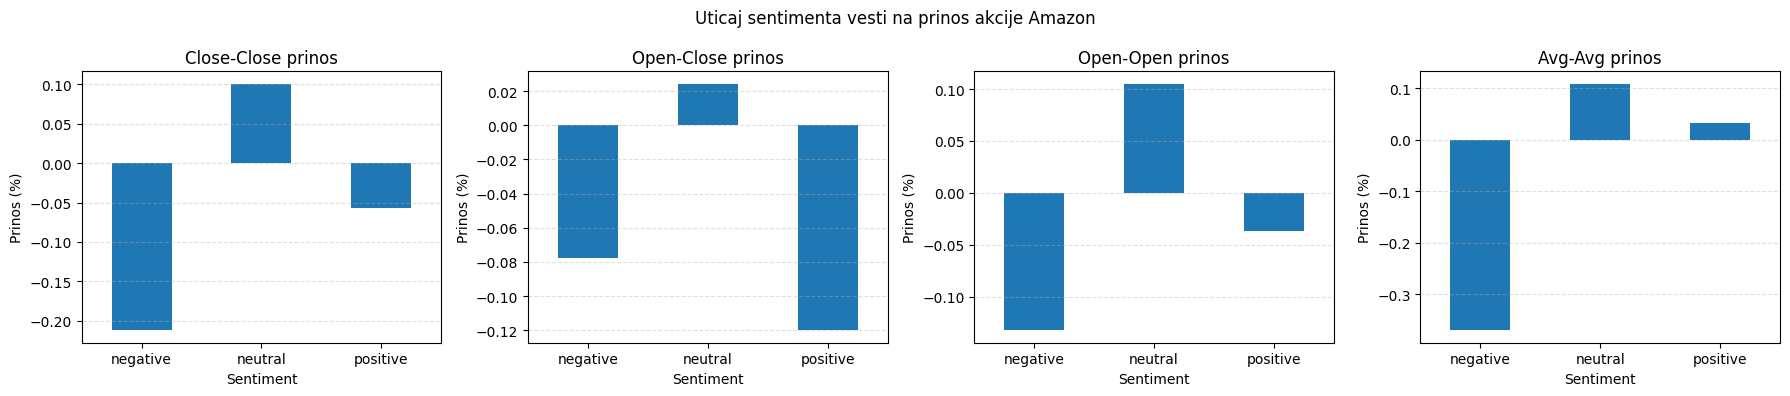

In [52]:
fig, axes = plt.subplots(1, 4, figsize=(18,4))

# Close-Close
returns_by_sentiment_percent["return_close_close"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Close-Close prinos")

# Open-Close
returns_by_sentiment_percent["return_open_close"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Open-Close prinos")

# Open-Open
returns_by_sentiment_percent["return_open_open"].plot(kind="bar", ax=axes[2])
axes[2].set_title("Open-Open prinos")

# Avg-Avg
returns_by_sentiment_percent["return_avg_avg"].plot(kind="bar", ax=axes[3])
axes[3].set_title("Avg-Avg prinos")

for ax in axes:
    ax.set_xlabel("Sentiment")
    ax.set_ylabel("Prinos (%)")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle("Uticaj sentimenta vesti na prinos akcije Amazon")

plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

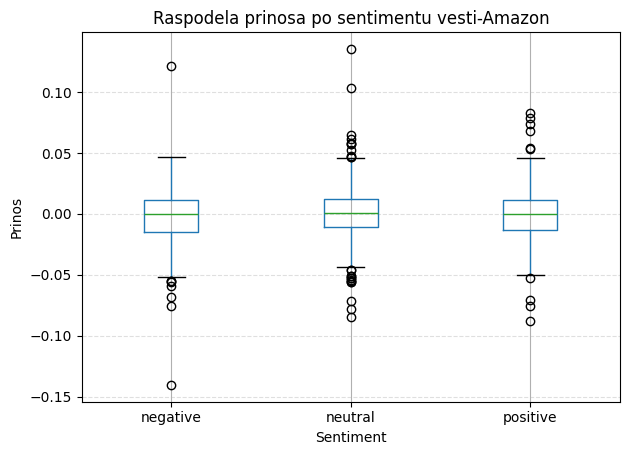

In [53]:
import matplotlib.pyplot as plt

# kopija podataka
df_daily = daily_sentiment.copy()

# formiranje grupa na osnovu daily_sentiment_class
df_daily["sentiment_group"] = pd.cut(
    df_daily["daily_sentiment_class"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
)

# boxplot
plt.figure(figsize=(6,4))

df_daily.boxplot(
    column="return_close_close",
    by="sentiment_group"
)

plt.title("Raspodela prinosa po sentimentu vesti-Amazon")
plt.suptitle("")  # uklanja default naslov
plt.xlabel("Sentiment")
plt.ylabel("Prinos")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

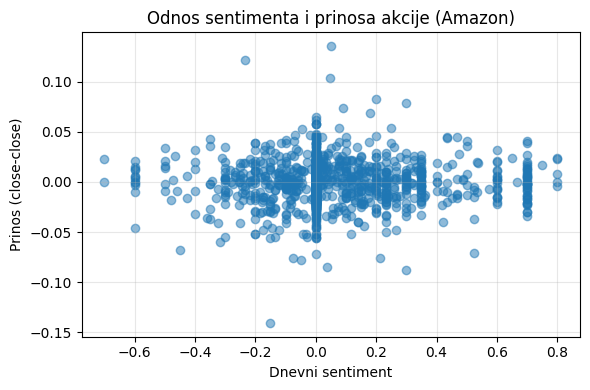

In [54]:
import matplotlib.pyplot as plt

# uklonjeno NaN
df_daily = daily_sentiment.dropna(subset=["daily_sentiment_score", "return_close_close"])

plt.figure(figsize=(6,4))

plt.scatter(
    df_daily["daily_sentiment_score"],
    df_daily["return_close_close"],
    alpha=0.5
)

plt.title("Odnos sentimenta i prinosa akcije (Amazon)")
plt.xlabel("Dnevni sentiment")
plt.ylabel("Prinos (close-close)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [58]:
amzn_tagged["date"] = pd.to_datetime(amzn_tagged["date"])
amzn_prices["date"] = pd.to_datetime(amzn_prices["date"])

amzn_tagged = amzn_tagged.sort_values("date")
amzn_prices = amzn_prices.sort_values("date")

In [63]:
extra = pd.merge_asof(
    amzn_tagged.sort_values("date"),
    amzn_prices[[
        "date",
        "close_t2", "close_t3",
        "high_t1", "high_t2", "high_t3",
        "low_t1", "low_t2", "low_t3"
    ]].sort_values("date"),
    on="date",
    direction="forward"
)

In [64]:
for col in [
    "close_t2", "close_t3",
    "high_t1", "high_t2", "high_t3",
    "low_t1", "low_t2", "low_t3"
]:
    amzn_tagged[col] = extra[col]

In [65]:
amzn_final = amzn_tagged.copy()

In [66]:
amzn_final["return_close_close"] = (
    amzn_final["close_t1"] - amzn_final["close_t"]
) / amzn_final["close_t"]

amzn_final["return_2d"] = (
    amzn_final["close_t2"] - amzn_final["close_t"]
) / amzn_final["close_t"]

amzn_final["return_3d"] = (
    amzn_final["close_t3"] - amzn_final["close_t"]
) / amzn_final["close_t"]

# targeti
amzn_final["y_1d"] = (amzn_final["return_close_close"] > 0).astype(int)
amzn_final["y_2d"] = (amzn_final["return_2d"] > 0).astype(int)
amzn_final["y_3d"] = (amzn_final["return_3d"] > 0).astype(int)

# profesorov
amzn_final["max_high_3d"] = amzn_final[["high_t1","high_t2","high_t3"]].max(axis=1)
amzn_final["min_low_3d"] = amzn_final[["low_t1","low_t2","low_t3"]].min(axis=1)

amzn_final["y_prof_3d"] = (
    abs(amzn_final["max_high_3d"] - amzn_final["close_t"]) >
    abs(amzn_final["min_low_3d"] - amzn_final["close_t"])
).astype(int)

amzn_final["company"] = "AMZN"

In [67]:
amzn_final.columns

Index(['date', 'title', 'content', 'link', 'symbols', 'tags',
       'sentiment_polarity', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos',
       'year', 'close_t', 'close_t1', 'open_t1', 'open_t2', 'avg_t', 'avg_t1',
       'return_close_close', 'return_open_close', 'return_open_open',
       'return_avg_avg', 'direction_close_close', 'direction_open_close',
       'direction_open_open', 'direction_avg_avg', 'text_for_ie', 'sentiment',
       'sentiment_score', 'topic', 'date_only', 'sentiment_num', 'close_t2',
       'close_t3', 'high_t1', 'high_t2', 'high_t3', 'low_t1', 'low_t2',
       'low_t3', 'return_2d', 'return_3d', 'y_1d', 'y_2d', 'y_3d',
       'max_high_3d', 'min_low_3d', 'y_prof_3d', 'company'],
      dtype='object')

In [68]:
amzn_final.to_csv("/content/drive/MyDrive/amzn_final.csv", index=False)